In [1]:
# Exploratory Data Analysis 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# plot style 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [3]:
# loading the data
train = pd.read_csv("/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/data/train.csv")
test = pd.read_csv("/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/data/test.csv")

In [4]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (1460, 81)
Test shape: (1459, 80)


In [5]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000,1460.000,1201.000,1460.000,1460.000,1460.000,1460.000,1460.000,1452.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1379.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000
mean,730.500,56.897,70.050,10516.828,6.099,5.575,1971.268,1984.866,103.685,443.640,46.549,567.240,1057.429,1162.627,346.992,5.845,1515.464,0.425,0.058,1.565,0.383,2.866,1.047,6.518,0.613,1978.506,1.767,472.980,94.245,46.660,21.954,3.410,15.061,2.759,43.489,6.322,2007.816,180921.196
std,421.610,42.301,24.285,9981.265,1.383,1.113,30.203,20.645,181.066,456.098,161.319,441.867,438.705,386.588,436.528,48.623,525.480,0.519,0.239,0.551,0.503,0.816,0.220,1.625,0.645,24.690,0.747,213.805,125.339,66.256,61.119,29.317,55.757,40.177,496.123,2.704,1.328,79442.503
min,1.000,20.000,21.000,1300.000,1.000,1.000,1872.000,1950.000,0.000,0.000,0.000,0.000,0.000,334.000,0.000,0.000,334.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,1900.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,2006.000,34900.000
25%,365.750,20.000,59.000,7553.500,5.000,5.000,1954.000,1967.000,0.000,0.000,0.000,223.000,795.750,882.000,0.000,0.000,1129.500,0.000,0.000,1.000,0.000,2.000,1.000,5.000,0.000,1961.000,1.000,334.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.000,2007.000,129975.000
50%,730.500,50.000,69.000,9478.500,6.000,5.000,1973.000,1994.000,0.000,383.500,0.000,477.500,991.500,1087.000,0.000,0.000,1464.000,0.000,0.000,2.000,0.000,3.000,1.000,6.000,1.000,1980.000,2.000,480.000,0.000,25.000,0.000,0.000,0.000,0.000,0.000,6.000,2008.000,163000.000
75%,1095.250,70.000,80.000,11601.500,7.000,6.000,2000.000,2004.000,166.000,712.250,0.000,808.000,1298.250,1391.250,728.000,0.000,1776.750,1.000,0.000,2.000,1.000,3.000,1.000,7.000,1.000,2002.000,2.000,576.000,168.000,68.000,0.000,0.000,0.000,0.000,0.000,8.000,2009.000,214000.000
max,1460.000,190.000,313.000,215245.000,10.000,9.000,2010.000,2010.000,1600.000,5644.000,1474.000,2336.000,6110.000,4692.000,2065.000,572.000,5642.000,3.000,2.000,3.000,2.000,8.000,3.000,14.000,3.000,2010.000,4.000,1418.000,857.000,547.000,552.000,508.000,480.000,738.000,15500.000,12.000,2010.000,755000.000


In [8]:
train.describe(include="object")

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198


In [9]:
num_features = train.select_dtypes(include=['number']).columns
num_features


Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [10]:
print(f"Count of Numerical Features: {len(num_features)}")

Count of Numerical Features: 38


In [11]:
cat_features = train.select_dtypes(include=['object', 'category']).columns
cat_features


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [12]:
print(f"Count of Categorical Features: {len(cat_features)}")

Count of Categorical Features: 43


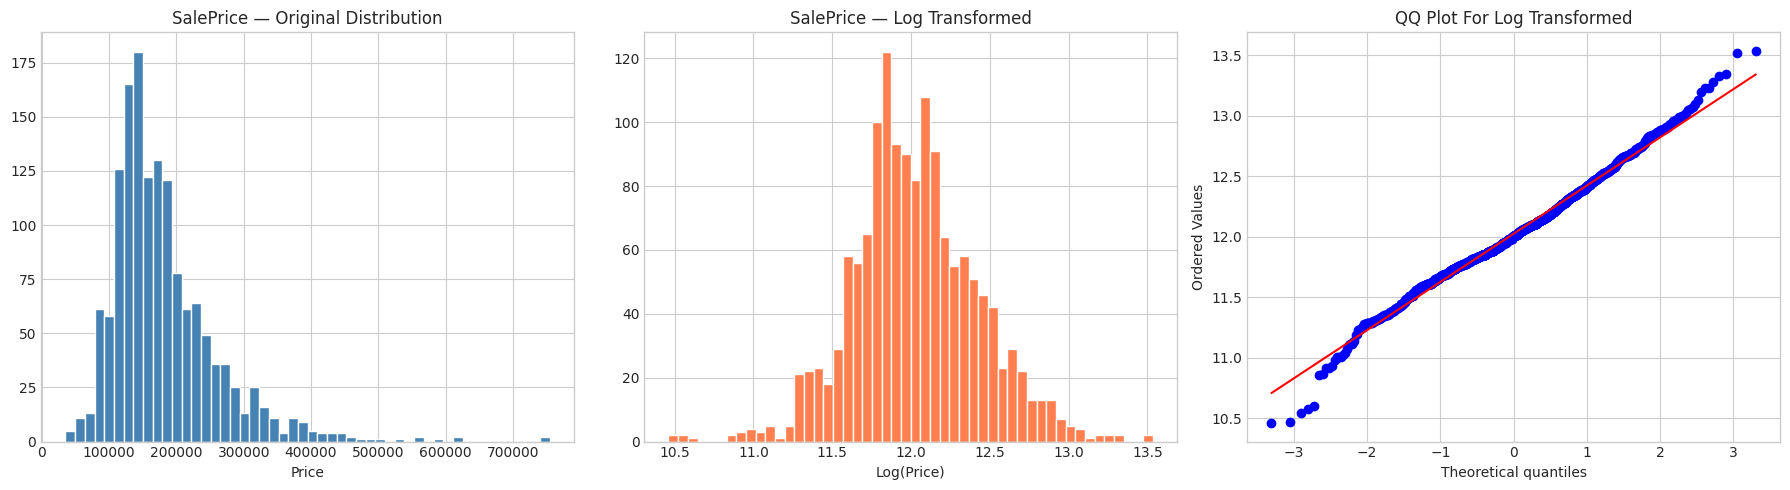

Skewness original: 1.8829
Skewness log-transformed: 0.1213


In [13]:
# target Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Original distribution
axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice — Original Distribution') 
axes[0].set_xlabel('Price')
#Log transformed distribution 
axes[1].hist(np.log1p(train['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('SalePrice — Log Transformed')
axes[1].set_xlabel('Log(Price)')
#QQ Plot —> tests normality 
stats.probplot(np.log1p(train['SalePrice']), plot=axes[2])
axes[2].set_title('QQ Plot For Log Transformed')

plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#Skewness before and after
print(f"Skewness original: {train['SalePrice'].skew():.4f}")
print(f"Skewness log-transformed: {np.log1p(train['SalePrice']).skew():.4f}")
#note
#-0.5 to 0.5 Symmetrical
#−1 to −0.5 or 0.5 to 1 Moderately Skewed
#< -1 or > 1 Highly Skewed

In [14]:
# missing values
def missing_values_analysis(df):
    missing = df.isnull().sum()
    
    missing = missing[missing > 0]
    
    missing_percent = (missing / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_percent
    }).sort_values('Missing %', ascending=False)
    
    return missing_df

train_missing = missing_values_analysis(train)
print("=== TRAINING_DATA MISSING VALUES ===")
train_missing



=== TRAINING_DATA MISSING VALUES ===


,Missing Count,Missing %
PoolQC,1453,99.521
MiscFeature,1406,96.301
Alley,1369,93.767
Fence,1179,80.753
MasVnrType,872,59.726
FireplaceQu,690,47.260
LotFrontage,259,17.740
GarageType,81,5.548
GarageYrBlt,81,5.548
GarageFinish,81,5.548


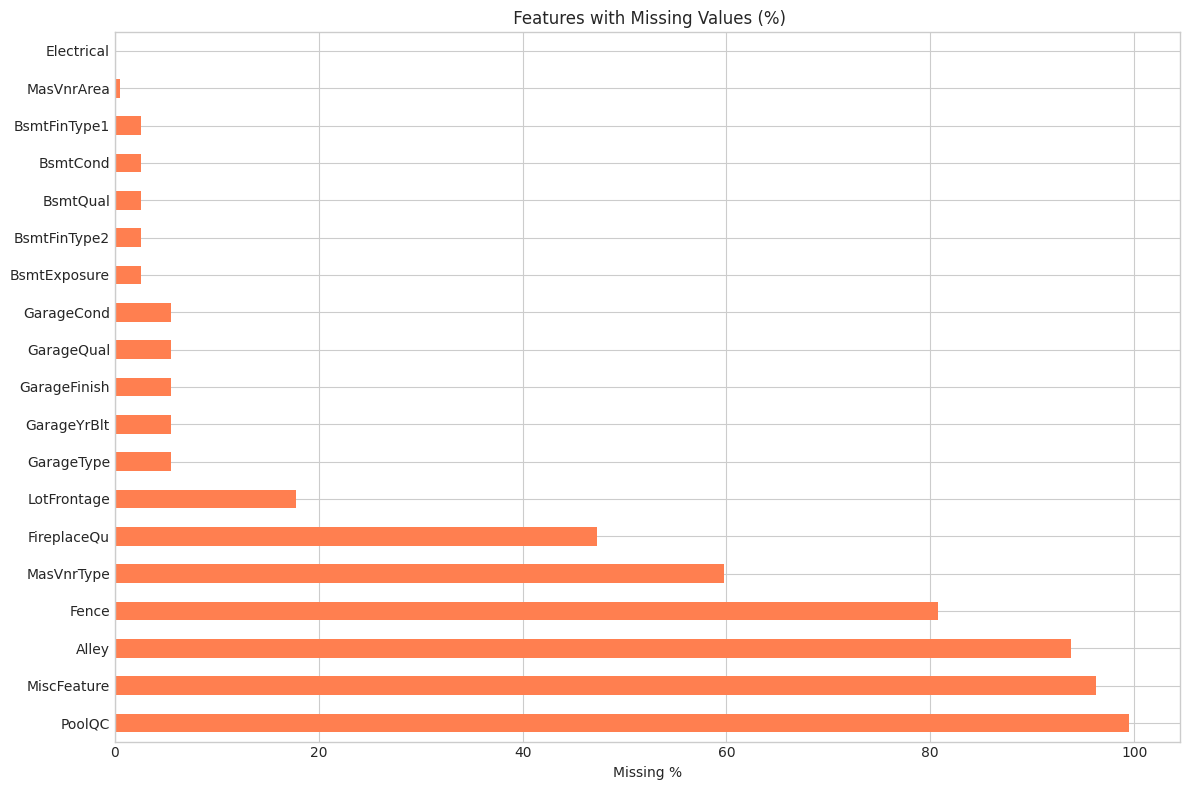

In [15]:
plt.figure(figsize=(12, 8))
train_missing['Missing %'].plot(kind='barh', color='coral')
plt.title(' Features with Missing Values (%)')
plt.xlabel('Missing %')
plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
num_features = train.select_dtypes(include=[np.number]).columns.tolist()
num_features.remove('SalePrice')
num_features.remove('Id')

# Skewness of all numerical features
skewness = train[num_features].skew().sort_values(ascending=False)

skewness



MiscVal         24.477
PoolArea        14.828
LotArea         12.208
3SsnPorch       10.304
LowQualFinSF     9.011
KitchenAbvGr     4.488
BsmtFinSF2       4.255
ScreenPorch      4.122
BsmtHalfBath     4.103
EnclosedPorch    3.090
MasVnrArea       2.669
OpenPorchSF      2.364
LotFrontage      2.164
BsmtFinSF1       1.686
WoodDeckSF       1.541
TotalBsmtSF      1.524
MSSubClass       1.408
1stFlrSF         1.377
GrLivArea        1.367
BsmtUnfSF        0.920
2ndFlrSF         0.813
OverallCond      0.693
TotRmsAbvGrd     0.676
HalfBath         0.676
Fireplaces       0.650
BsmtFullBath     0.596
OverallQual      0.217
MoSold           0.212
BedroomAbvGr     0.212
GarageArea       0.180
YrSold           0.096
FullBath         0.037
GarageCars      -0.343
YearRemodAdd    -0.504
YearBuilt       -0.613
GarageYrBlt     -0.649
dtype: float64

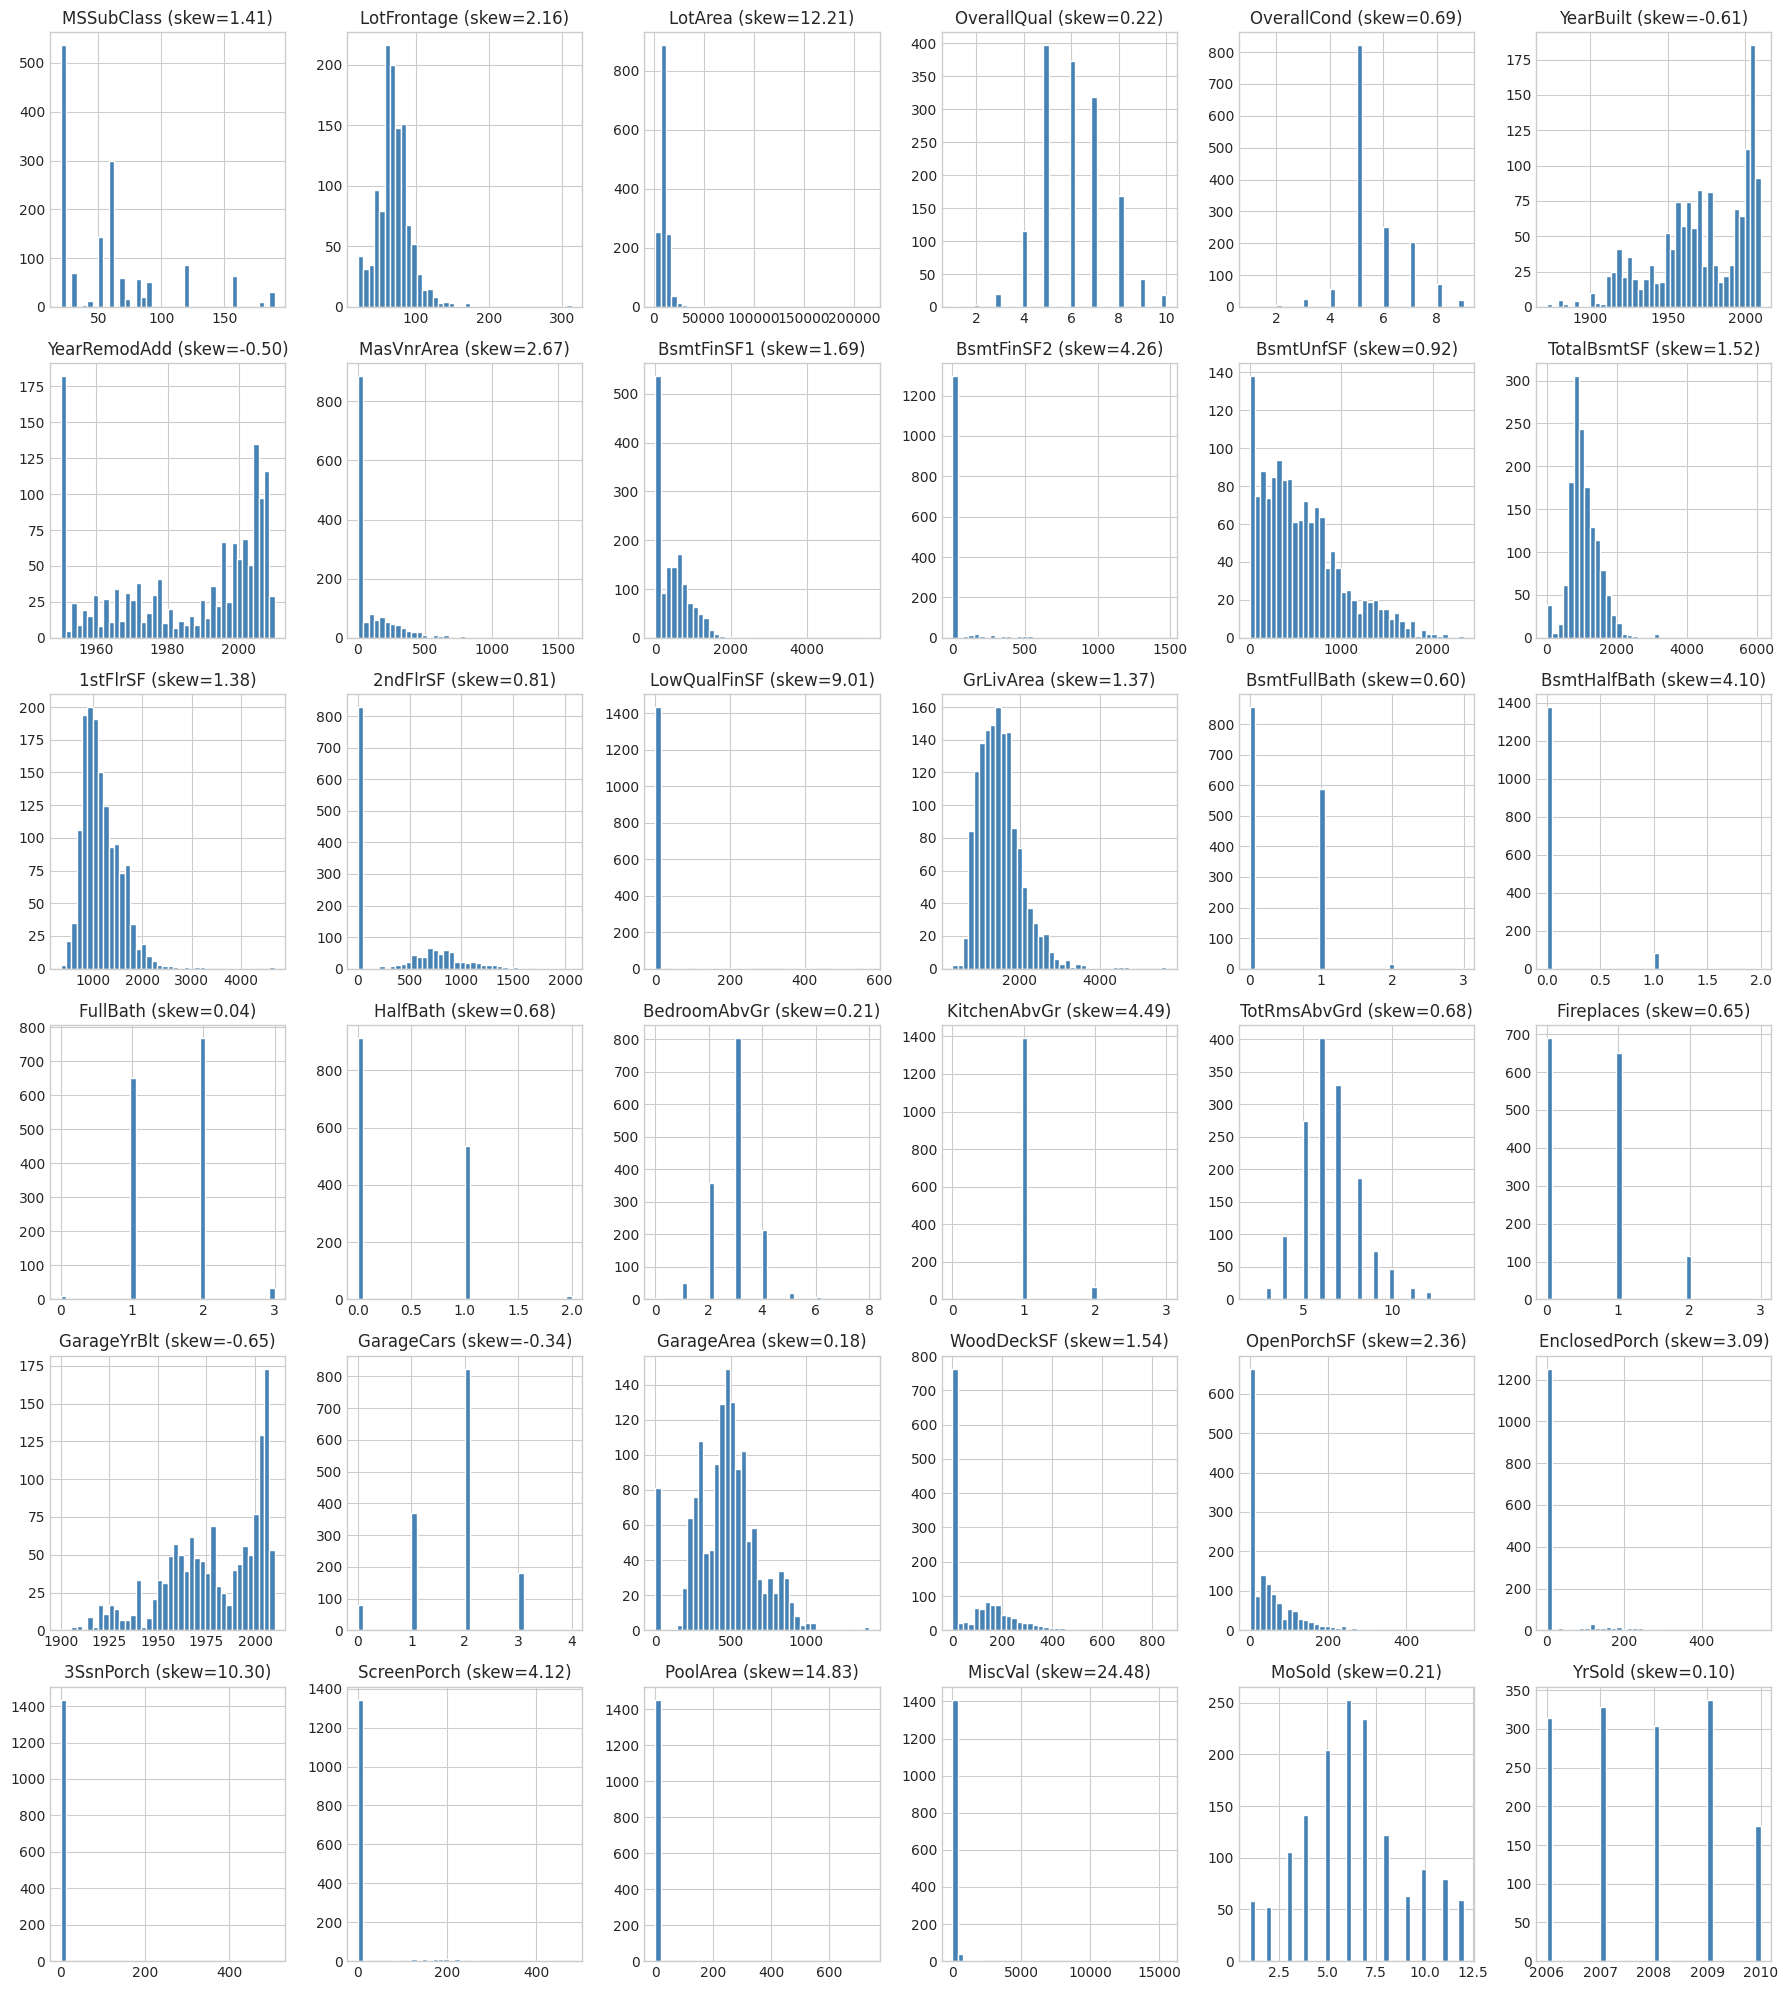

In [17]:
#Distribution plots for numerical features
fig, axes = plt.subplots(6,6, figsize=(18, 20))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    axes[i].hist(train[feature].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{feature} (skew={train[feature].skew():.2f})')

plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Correlation with SalePrice
correlation = train[num_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')

correlation_sorted = correlation.abs().sort_values(ascending=False)


correlation_sorted



OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
GarageYrBlt     0.486
MasVnrArea      0.477
Fireplaces      0.467
BsmtFinSF1      0.386
LotFrontage     0.352
WoodDeckSF      0.324
2ndFlrSF        0.319
OpenPorchSF     0.316
HalfBath        0.284
LotArea         0.264
BsmtFullBath    0.227
BsmtUnfSF       0.214
BedroomAbvGr    0.168
KitchenAbvGr    0.136
EnclosedPorch   0.129
ScreenPorch     0.111
PoolArea        0.092
MSSubClass      0.084
OverallCond     0.078
MoSold          0.046
3SsnPorch       0.045
YrSold          0.029
LowQualFinSF    0.026
MiscVal         0.021
BsmtHalfBath    0.017
BsmtFinSF2      0.011
Name: SalePrice, dtype: float64

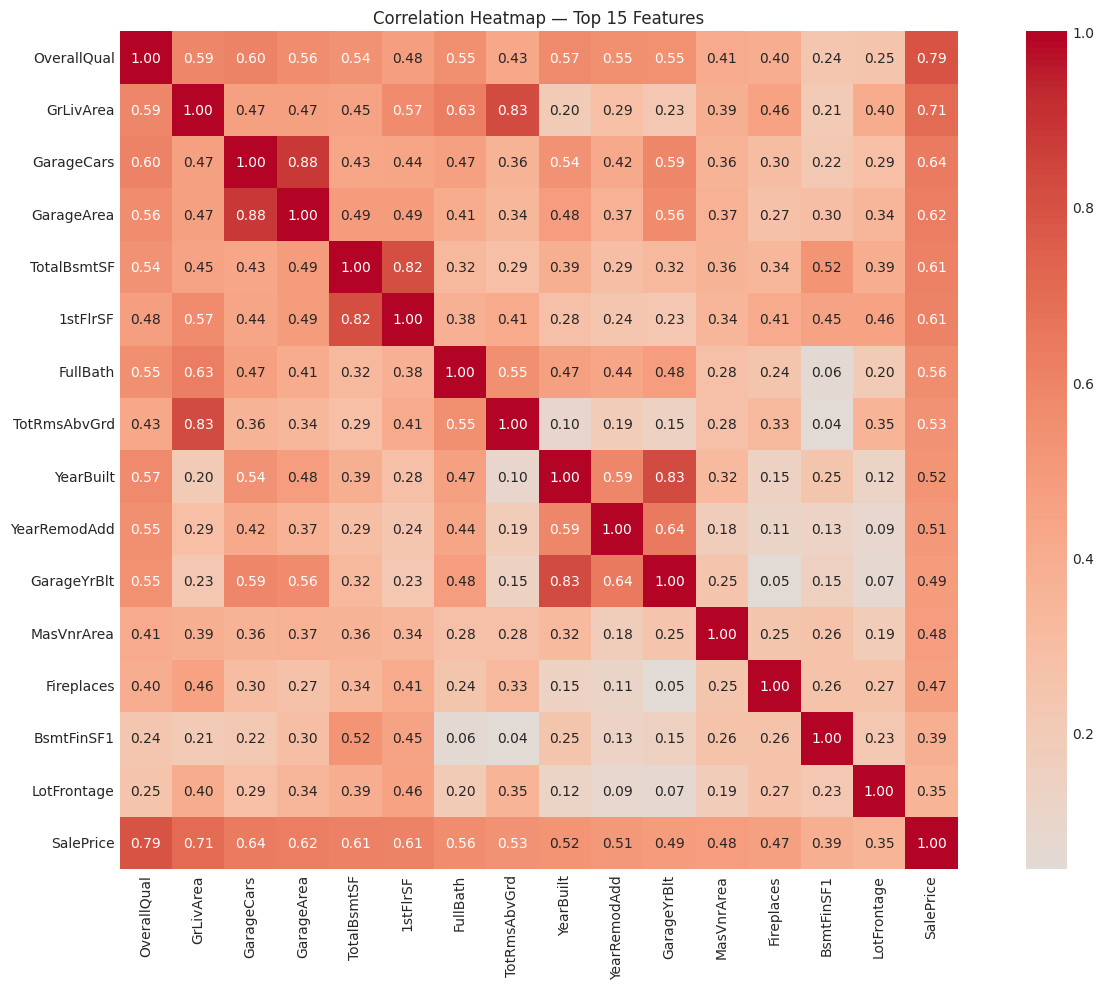

In [19]:
# Heatmap of top 15 features
top_features = correlation_sorted.head(15).index.tolist() + ['SalePrice']

plt.figure(figsize=(14, 10))
sns.heatmap(
    train[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Correlation Heatmap — Top 15 Features')
plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

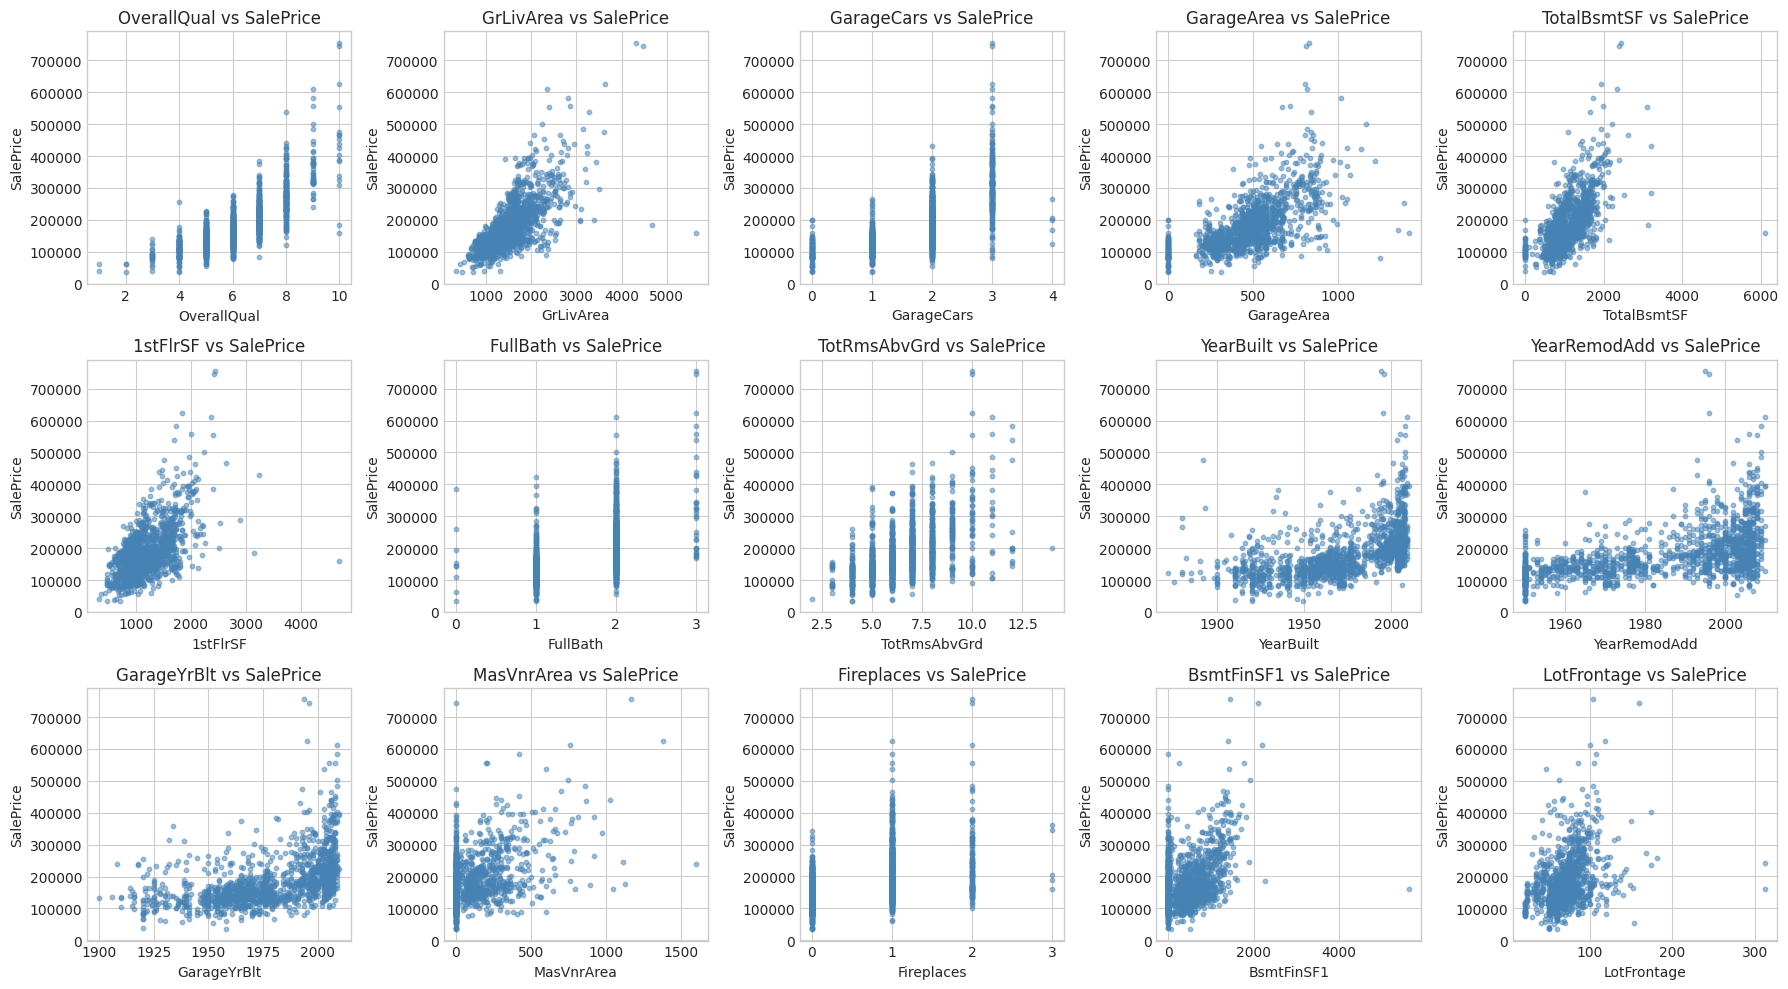

In [20]:
top_corr_features = correlation_sorted.head(15).index.tolist()

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top_corr_features):
    axes[i].scatter(train[feature], train['SalePrice'], alpha=0.5, color='steelblue', s=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feature} vs SalePrice')

plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

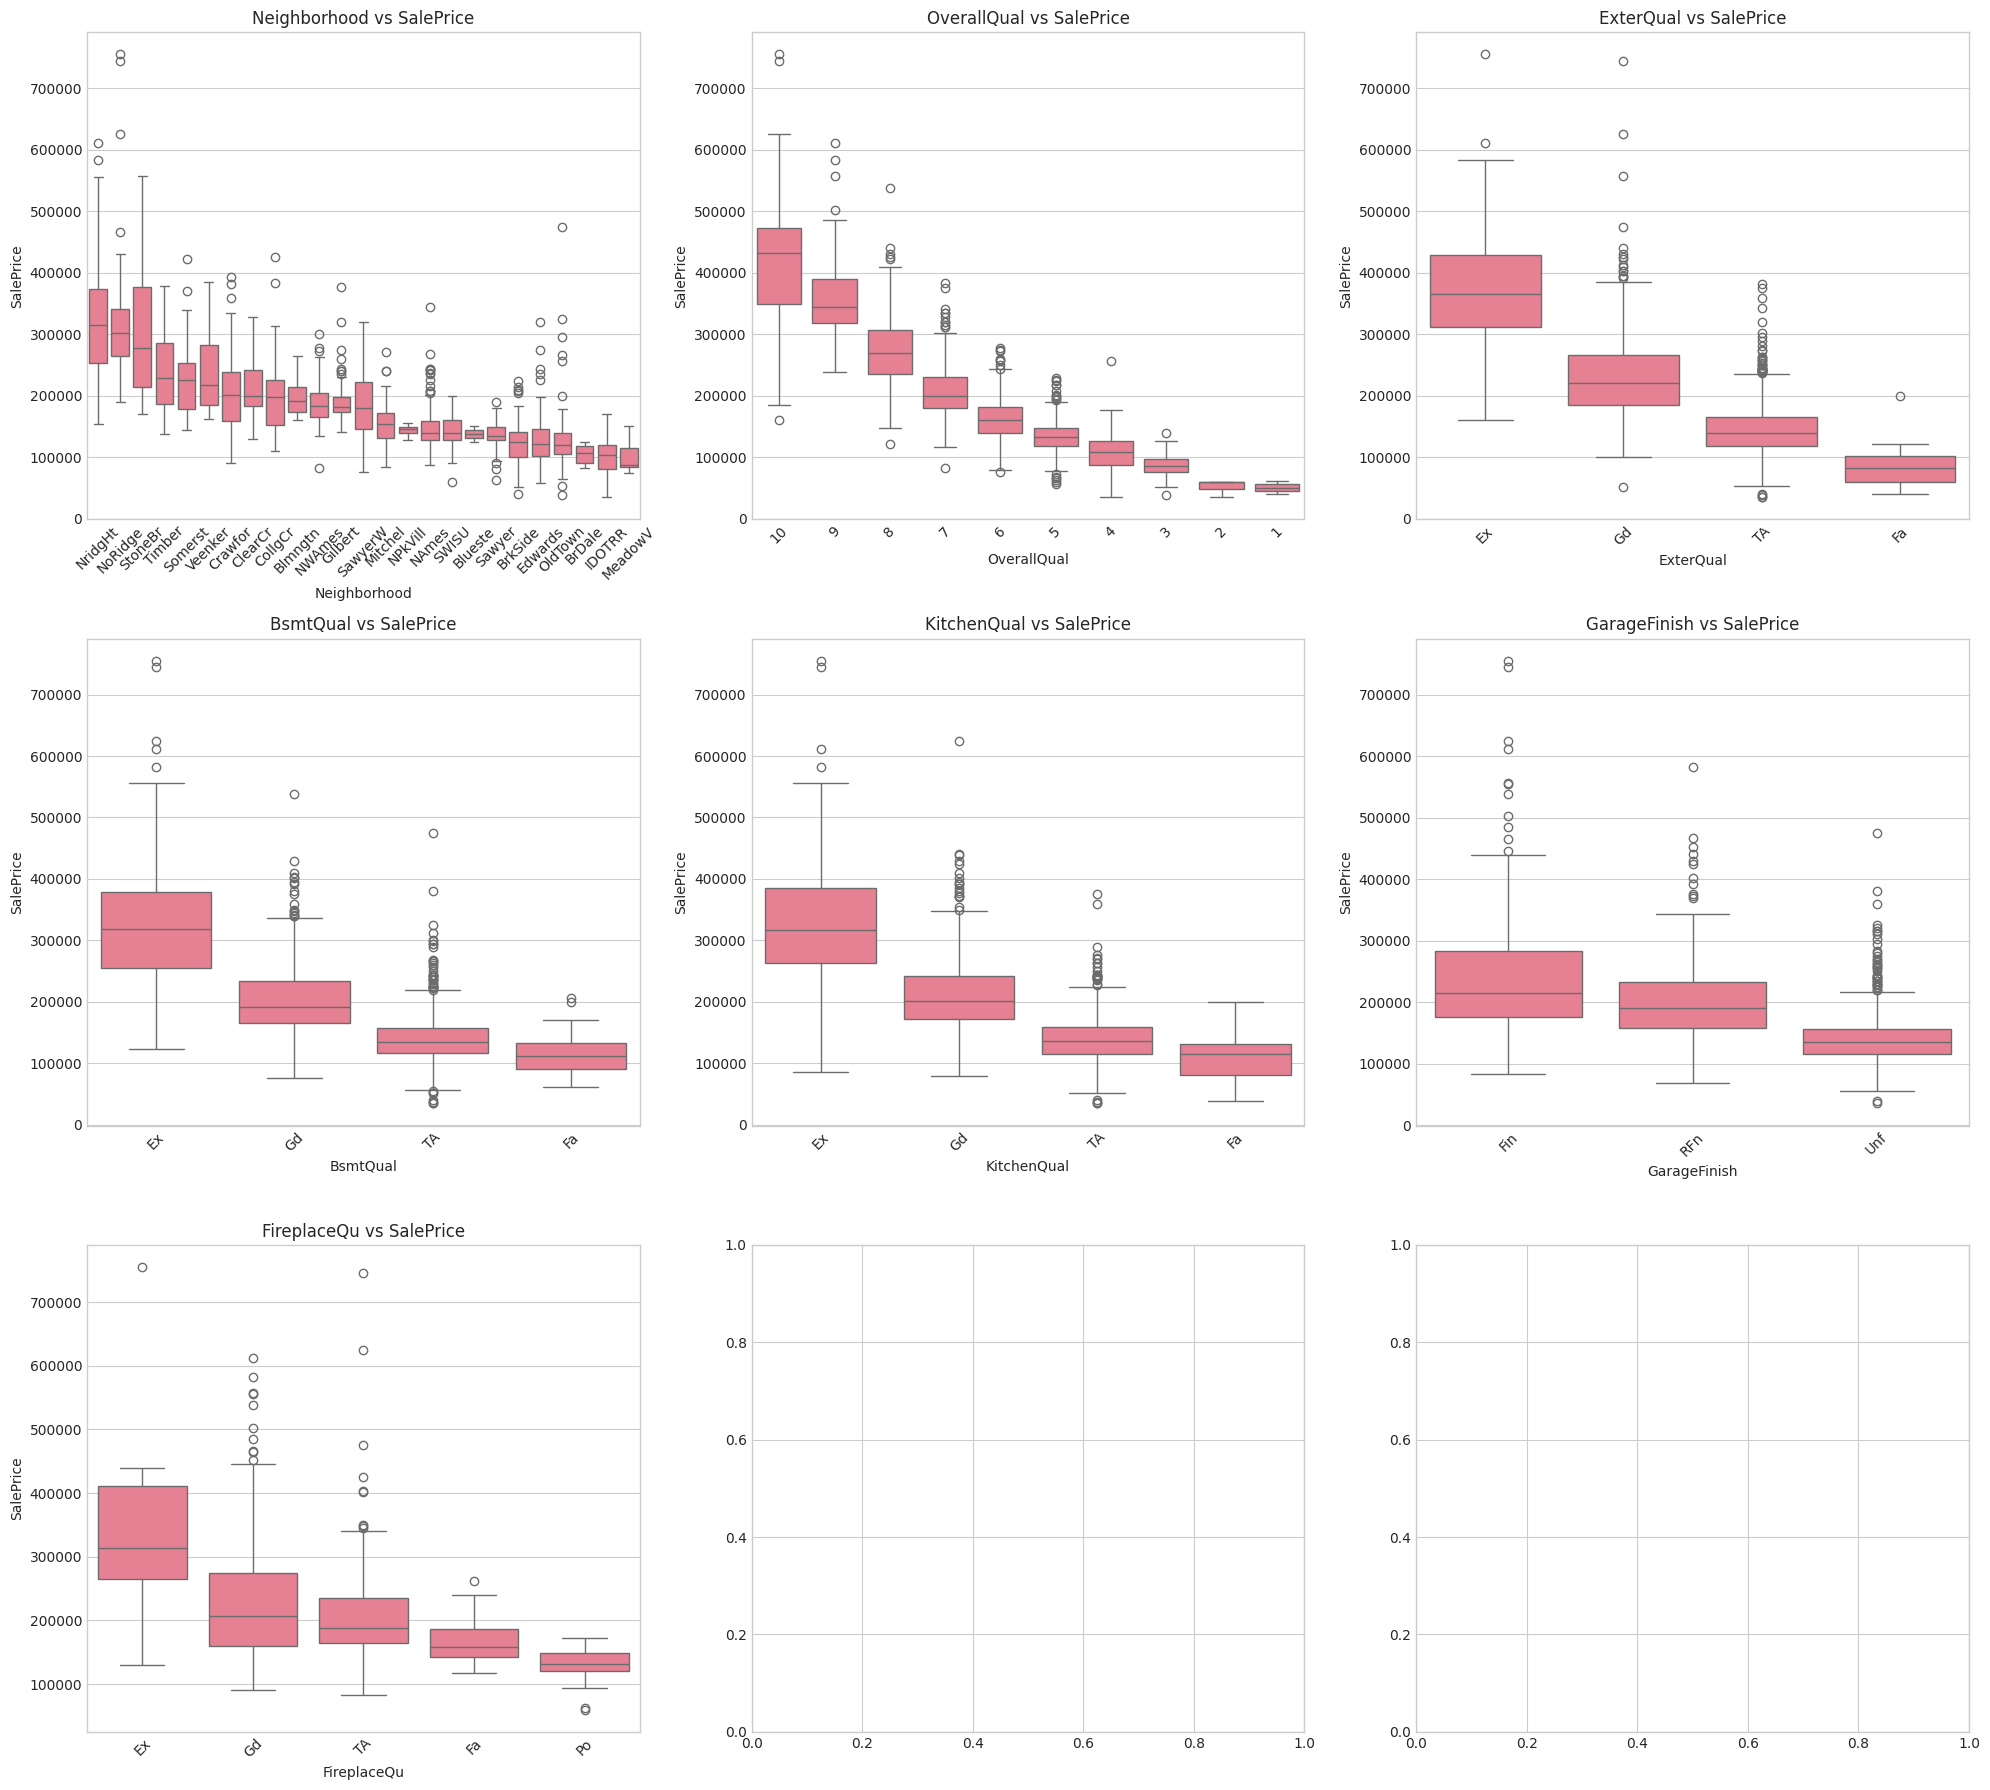

In [21]:
# Most impactful categorical features
#group target with most important cat features
important_cat = ['Neighborhood', 'OverallQual', 'ExterQual',
                 'BsmtQual', 'KitchenQual', 'GarageFinish', 'FireplaceQu']

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

for i, feature in enumerate(important_cat):
    order = train.groupby(feature)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=feature, y='SalePrice', order=order, ax=axes[i])
    axes[i].set_title(f'{feature} vs SalePrice')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

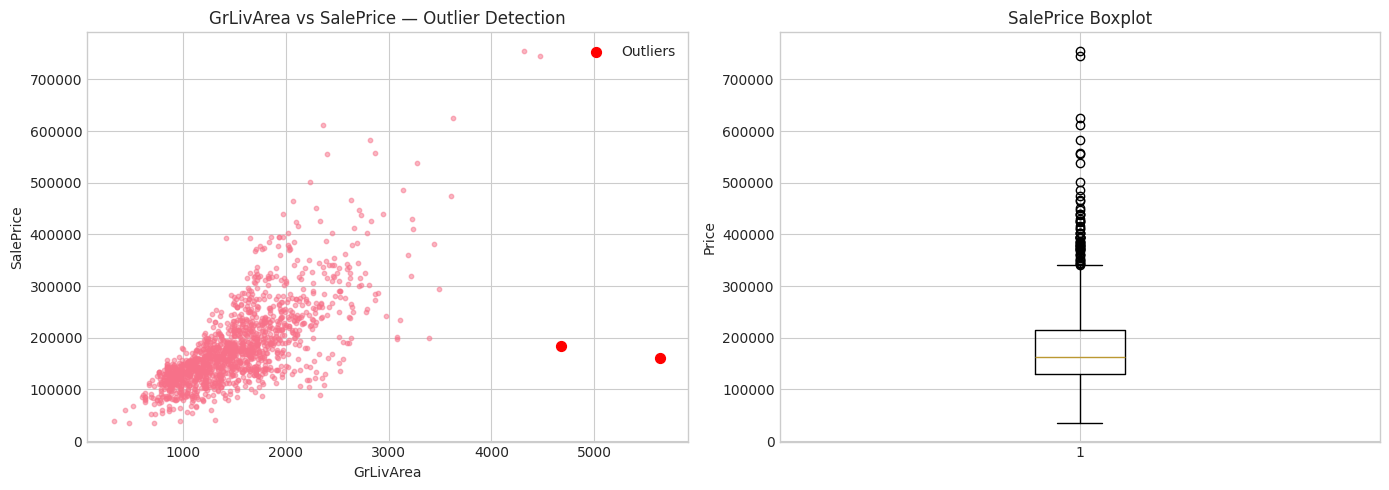

Suspicious outliers (large house, low price):
      GrLivArea  SalePrice Neighborhood  OverallQual
523        4676     184750      Edwards           10
1298       5642     160000      Edwards           10


In [22]:
# Two most important features — check for outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GrLivArea outliers
axes[0].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, s=10)
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')
axes[0].set_title('GrLivArea vs SalePrice — Outlier Detection')

# Mark suspicious points
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
axes[0].scatter(outliers['GrLivArea'], outliers['SalePrice'],
                color='red', s=50, label='Outliers', zorder=5)
axes[0].legend()

# Boxplot for SalePrice
axes[1].boxplot(train['SalePrice'])
axes[1].set_title('SalePrice Boxplot')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Suspicious outliers (large house, low price):")
print(outliers[['GrLivArea', 'SalePrice', 'Neighborhood', 'OverallQual']])